# XGBoost

XGBoost (eXtreme Gradient Boosting) is a highly efficient and widely used implementation of the **Gradient Boosting** algorithm.
While Random Forests used **bagging** (training trees in paralle and averaging their results), XGBoost uses **boosting**, which is an ensemble technique that builds models sequentially. Each new model is trained to coorect the errors of the previous one. This 'boosting' of weak learners (typically DTs) turns them into a single, strong learner.

**How It Works: The Additive and Sequential Process**
The core idea of XGBoost is to build an additive model. It starts with an initial simple prediction (e.g., the average of the target values) and then iteratively adds new trees to the model. Each new tree is trained to predict the residuals (the errors) of the previous step.

1. Initial Prediction: The model starts with a simple base prediction.

2. Calculate Residuals: It calculates the difference between the actual values and the current predictions (the residuals).

3. Train a New Tree: A new, simple Decision Tree is trained on the residuals, with the goal of minimizing these errors.

4. Update the Model: The new tree's prediction is added to the total model, but it is scaled by a learning rate (also called eta). The learning rate is a crucial hyperparameter that prevents the model from overfitting by making each correction step smaller.


This process is repeated for a specified number of boosting rounds (n_estimators). By focusing on the data points that were hardest to predict correctly in the previous steps, XGBoost effectively "boosts" the model's performance.

**Key Features and Advantages**
XGBoost is so popular in data science competitions and production environments because of several key features:

- Speed and Performance: It's highly optimized and can be run on multiple CPUs in parallel.

- Regularization: It includes built-in regularization terms (L1 and L2) to prevent overfitting, which makes it more robust than a standard Gradient Boosting implementation. These parameters are crucial for controlling model complexity.

- Handling Missing Values: It has an internal mechanism to handle missing values automatically.

- Flexibility: It can be used for both classification and regression problems.

The combination of this sequential, error-correcting process with robust optimization and regularization makes XGBoost an extremely powerful and reliable algorithm.



Training the XGBoost model...
Training complete.

XGBoost Model Accuracy: 97.00%
XGBoost ROC AUC Score: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        43
           1       1.00      0.95      0.97        57

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:04:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


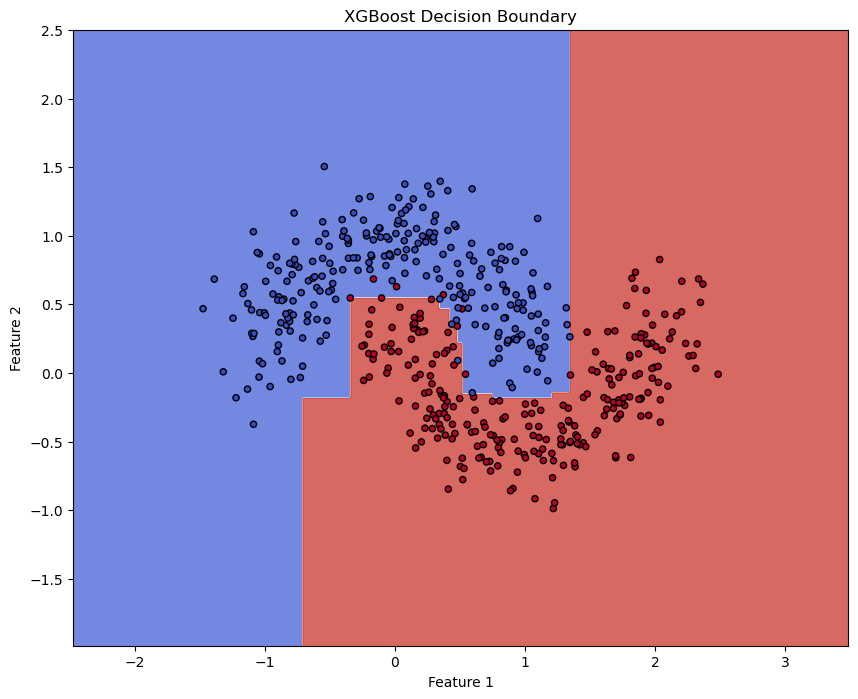

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.datasets import make_moons
import xgboost as xgb

# 1. Generate a more complex synthetic dataset
# make_moons creates two interleaving half-circles, which is a non-linear problem
# that a single Decision Tree might struggle with.
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Instantiate the XGBoost classifier
# Key hyperparameters to know for an interview:
# n_estimators: The number of boosting rounds (trees).
# learning_rate: The step size shrinkage to prevent overfitting.
# max_depth: The maximum depth of each individual tree.
model = xgb.XGBClassifier(
    n_estimators=100,          # The number of boosting rounds
    learning_rate=0.1,         # Prevents overfitting by making steps smaller
    max_depth=3,               # Depth of each tree
    use_label_encoder=False,   # Silences a deprecation warning
    eval_metric='logloss',     # Evaluation metric to use
    random_state=42
)

# 3. Fit the model to the training data
# This is where XGBoost sequentially builds the trees to correct previous errors.
print("Training the XGBoost model...")
model.fit(X_train, y_train)
print("Training complete.")

# 4. Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Get probabilities for ROC AUC

# 5. Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nXGBoost Model Accuracy: {accuracy * 100:.2f}%")
print(f"XGBoost ROC AUC Score: {roc_auc:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 6. Visualize the decision boundary
# This shows how the model separates the two classes.
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolors='k', cmap=plt.cm.coolwarm)
plt.title("XGBoost Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()



### Evaluation

A. Evaluation Metrics
Since XGBoost is an extremely flexible algorithm, the evaluation metrics you choose depend entirely on the task:

For Classification: The same metrics we discussed for Decision Trees and Random Forests apply. You would use Accuracy, Precision, Recall, F1-Score, and ROC AUC. The eval_metric='logloss' parameter we used in the code is one of the built-in metrics XGBoost uses during training to monitor its progress.

For Regression: If you were using XGBRegressor, you would use regression metrics such as Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R 
2
  Score.

B. The Main Improvement Concept: Hyperparameter Tuning and Regularization
XGBoost is known for having a lot of hyperparameters, which can make it very powerful but also prone to overfitting if not tuned correctly. The key to improving an XGBoost model is to master its hyperparameters, many of which control the built-in regularization.

The most important hyperparameters for an interview are:

n_estimators: The number of boosting rounds or trees. A higher number can lead to better performance but also increases the risk of overfitting and computational cost.

learning_rate (eta): The step size at each boosting iteration. A smaller learning rate requires more trees (n_estimators) but makes the model more robust to overfitting. This is a critical parameter.

max_depth: The maximum depth of each individual tree. Limiting this is a classic way to prevent overfitting.

gamma: A parameter that controls minimum loss reduction required to make a further partition on a leaf node of the tree. A larger value leads to a more conservative, simpler model.

subsample: The fraction of samples to be used for fitting the individual base learners. A value less than 1.0 (e.g., 0.8) introduces randomness and helps prevent overfitting.

colsample_bytree: The fraction of features to be randomly sampled for each tree. Similar to RandomForestClassifier, this adds randomness and reduces overfitting.

### Regularization in XGBoost

XGBoost's strength lies in its built-in L1 (reg_alpha) and L2 (reg_lambda) regularization, which penalize complex models. By increasing these values, you can force the model to be simpler and more resistant to overfitting.

Just as with the Random Forest example, you can use a Grid Search to find the optimal combination of these hyperparameters for your specific problem.

In [5]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


# Generate the same dataset
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Define a dictionary of parameters to search over
# This is a good example of an interview-ready grid search setup
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

# Instantiate GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Accuracy: {grid_search.best_score_:.2f}")

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:07:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:07:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:07:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:07:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best Accuracy: 0.96


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:07:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:07:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:07:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:07:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i